**OBJECTIVES**

This project aims to predict patient "No-Shows" using a Random Forest Classifier. By identifying high-risk appointments, the clinic can proactively manage scheduling to recover lost revenue and improve patient care.

In [2]:
# mount drive to import csv files

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# import used libraries

import pandas as pd                                       # for data tables [DataFrames]
import matplotlib.pyplot as plt                           # foundation for charts
import seaborn as sns                                     # for professional looking charts
import numpy as np                                        # handles the heavy math
import warnings                                           # Suppress all warnings
warnings.filterwarnings('ignore')

# Scikit-Learn: the "brain" of the operation

from sklearn.model_selection import train_test_split      # to split my data
from imblearn.over_sampling import SMOTE                  # tool to balance out my data
from sklearn.ensemble import RandomForestClassifier       # AI model that learn the patterns
from sklearn.metrics import classification_report         # to see how the model performed
from sklearn.metrics import confusion_matrix              # a map showing exactly where the model got confused

In [4]:
# loading all CSV files

patients = pd.read_csv("/content/drive/MyDrive/Tableau Datasets/patients.csv")
appointments = pd.read_csv("/content/drive/MyDrive/Tableau Datasets/appointments.csv")
billing = pd.read_csv("/content/drive/MyDrive/Tableau Datasets/billing.csv")
diagnoses = pd.read_csv("/content/drive/MyDrive/Tableau Datasets/diagnoses.csv")
doctors = pd.read_csv("/content/drive/MyDrive/Tableau Datasets/doctors.csv")
medications = pd.read_csv("/content/drive/MyDrive/Tableau Datasets/medications.csv")

In [5]:
# using appointment table as my Anchor Table

healthcare_df = appointments.copy()

In [6]:
# merging tables together using left joins so no appointment is missing

healthcare_df = healthcare_df.merge(patients, on="patient_id", how="left")
healthcare_df = healthcare_df.merge(doctors, on="doctor_id", how="left")
healthcare_df = healthcare_df.merge(billing, on="appointment_id", how="left")
healthcare_df = healthcare_df.merge(diagnoses, on="appointment_id", how="left")

In [7]:
# medication is grouped by patient_id and counted by med_id as one patient can have multiple medications

med_agg = medications.groupby("patient_id").agg({
    "med_id": "count"
}).rename(columns={"med_id": "num_medication"}).reset_index()

In [8]:
# merging the medication count into the main anchor table

healthcare_df = healthcare_df.merge(med_agg, on="patient_id", how="left")

In [9]:
# DataFrame Exploration [shape]

healthcare_df.shape

(31845, 23)

In [10]:
# DataFrame Exploration [top 5]

healthcare_df.head()

,appointment_id,patient_id,doctor_id,appointment_date,status,visit_reason,first_name,last_name,gender,date_of_birth,...,specialty,clinic_location,bill_id,amount,insurance_covered,patient_paid,diagnosis_id,diagnosis_code,diagnosis_description,num_medication
0,1,907,44,2025-07-08,Completed,Key current shoulder.,Margaret,Burns,F,1941-06-10,...,General Medicine,Seattle,655.0,483.0,160.0,323.0,NaN,NaN,NaN,1.0
1,1,907,44,2025-07-08,Completed,Key current shoulder.,Margaret,Burns,F,1941-06-10,...,General Medicine,Seattle,13754.0,370.0,261.0,109.0,NaN,NaN,NaN,1.0
2,2,1911,66,2025-06-29,Completed,Sense huge benefit.,Joshua,Montgomery,F,1970-06-07,...,General Medicine,Portland,1947.0,198.0,197.0,1.0,NaN,NaN,NaN,1.0
3,2,1911,66,2025-06-29,Completed,Sense huge benefit.,Joshua,Montgomery,F,1970-06-07,...,General Medicine,Portland,3586.0,372.0,230.0,142.0,NaN,NaN,NaN,1.0
4,2,1911,66,2025-06-29,Completed,Sense huge benefit.,Joshua,Montgomery,F,1970-06-07,...,General Medicine,Portland,15239.0,562.0,537.0,25.0,NaN,NaN,NaN,1.0


In [11]:
# DataFrame Exploration [info]

healthcare_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31845 entries, 0 to 31844
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         31845 non-null  int64  
 1   patient_id             31845 non-null  int64  
 2   doctor_id              31845 non-null  int64  
 3   appointment_date       31845 non-null  object 
 4   status                 31845 non-null  object 
 5   visit_reason           31845 non-null  object 
 6   first_name             31845 non-null  object 
 7   last_name              31845 non-null  object 
 8   gender                 31845 non-null  object 
 9   date_of_birth          31845 non-null  object 
 10  city                   31845 non-null  object 
 11  insurance_provider     31845 non-null  object 
 12  doctor_name            31845 non-null  object 
 13  specialty              31845 non-null  object 
 14  clinic_location        31845 non-null  object 
 15  bi

In [12]:
# DataFrame Exploration [duplicated summation]

healthcare_df.duplicated().sum()

np.int64(0)

In [13]:
# DataFrame Exploration [is_null column summation]

healthcare_df.isnull().sum()

,0
appointment_id,0
patient_id,0
doctor_id,0
appointment_date,0
status,0
visit_reason,0
first_name,0
last_name,0
gender,0
date_of_birth,0


In [14]:
# creating columns for age using appointment_date - date_of_birth

healthcare_df['date_of_birth'] = pd.to_datetime(healthcare_df['date_of_birth'])           # conveting date_of_birth to datetime to calculate time differences

healthcare_df['appointment_date'] = pd.to_datetime(healthcare_df['appointment_date'])     # # conveting appointment_date to datetime to calculate time differences

healthcare_df['age'] = (healthcare_df['appointment_date'] - healthcare_df['date_of_birth']).dt.days // 365

In [15]:
# age binning for deeper insight [creating a logical life-stage groups]

bin = [0, 18, 35, 60, 100]
label =['Child', 'Young Adult', 'Adult', 'Senior']

# create a new age_group column

healthcare_df['age_group'] = pd.cut(healthcare_df['age'], bins=bin, labels=label)
healthcare_df.head()

,appointment_id,patient_id,doctor_id,appointment_date,status,visit_reason,first_name,last_name,gender,date_of_birth,...,bill_id,amount,insurance_covered,patient_paid,diagnosis_id,diagnosis_code,diagnosis_description,num_medication,age,age_group
0,1,907,44,2025-07-08,Completed,Key current shoulder.,Margaret,Burns,F,1941-06-10,...,655.0,483.0,160.0,323.0,NaN,NaN,NaN,1.0,84,Senior
1,1,907,44,2025-07-08,Completed,Key current shoulder.,Margaret,Burns,F,1941-06-10,...,13754.0,370.0,261.0,109.0,NaN,NaN,NaN,1.0,84,Senior
2,2,1911,66,2025-06-29,Completed,Sense huge benefit.,Joshua,Montgomery,F,1970-06-07,...,1947.0,198.0,197.0,1.0,NaN,NaN,NaN,1.0,55,Adult
3,2,1911,66,2025-06-29,Completed,Sense huge benefit.,Joshua,Montgomery,F,1970-06-07,...,3586.0,372.0,230.0,142.0,NaN,NaN,NaN,1.0,55,Adult
4,2,1911,66,2025-06-29,Completed,Sense huge benefit.,Joshua,Montgomery,F,1970-06-07,...,15239.0,562.0,537.0,25.0,NaN,NaN,NaN,1.0,55,Adult


In [16]:
# create the Target in the main DF

healthcare_df['Target'] = healthcare_df['status'].apply(lambda x: 0 if x == 'Completed' else 1)

# No-Show rate for each group

age_analysis = healthcare_df.groupby('age_group')['Target'].mean().sort_values(ascending=True)

print("No-Show Rate by Age Group (0.0 to 1.0):")
print(age_analysis)

No-Show Rate by Age Group (0.0 to 1.0):
age_group
Child          0.648739
Senior         0.653835
Adult          0.669160
Young Adult    0.685017
Name: Target, dtype: float64


In [17]:
# extracting the Month, Day of the Week, and Weekends to see if time plays a role in no-shows

healthcare_df['appointment_month'] = healthcare_df['appointment_date'].dt.month

healthcare_df['day_of_week'] = healthcare_df['appointment_date'].dt.dayofweek

healthcare_df['is_weekend'] = healthcare_df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
healthcare_df.head()

,appointment_id,patient_id,doctor_id,appointment_date,status,visit_reason,first_name,last_name,gender,date_of_birth,...,diagnosis_id,diagnosis_code,diagnosis_description,num_medication,age,age_group,Target,appointment_month,day_of_week,is_weekend
0,1,907,44,2025-07-08,Completed,Key current shoulder.,Margaret,Burns,F,1941-06-10,...,NaN,NaN,NaN,1.0,84,Senior,0,7,1,0
1,1,907,44,2025-07-08,Completed,Key current shoulder.,Margaret,Burns,F,1941-06-10,...,NaN,NaN,NaN,1.0,84,Senior,0,7,1,0
2,2,1911,66,2025-06-29,Completed,Sense huge benefit.,Joshua,Montgomery,F,1970-06-07,...,NaN,NaN,NaN,1.0,55,Adult,0,6,6,1
3,2,1911,66,2025-06-29,Completed,Sense huge benefit.,Joshua,Montgomery,F,1970-06-07,...,NaN,NaN,NaN,1.0,55,Adult,0,6,6,1
4,2,1911,66,2025-06-29,Completed,Sense huge benefit.,Joshua,Montgomery,F,1970-06-07,...,NaN,NaN,NaN,1.0,55,Adult,0,6,6,1


In [18]:
# creating a 'subset' variable with selected columns just for the model [using copy() so changes do not affect main DataFrame]

status_class_columns = ['age', 'gender', 'city', 'appointment_month', 'day_of_week', 'is_weekend', 'Target']
class_df = healthcare_df[status_class_columns].copy()
class_df

,age,gender,city,appointment_month,day_of_week,is_weekend,Target
0,84,F,Portland,7,1,0,0
1,84,F,Portland,7,1,0,0
2,55,F,Tacoma,6,6,1,0
3,55,F,Tacoma,6,6,1,0
4,55,F,Tacoma,6,6,1,0
...,...,...,...,...,...,...,...
31840,38,M,Portland,8,5,1,1
31841,38,M,Portland,8,5,1,1
31842,29,M,Portland,12,3,0,1
31843,54,F,Olympia,8,2,0,0


In [19]:
# turning gender into binary since the is just 'M' and 'F' gender classification

class_df['gender_bin'] = class_df['gender'].apply(lambda x: 0 if x == 'M' else 1)
class_df.head()

,age,gender,city,appointment_month,day_of_week,is_weekend,Target,gender_bin
0,84,F,Portland,7,1,0,0,1
1,84,F,Portland,7,1,0,0,1
2,55,F,Tacoma,6,6,1,0,1
3,55,F,Tacoma,6,6,1,0,1
4,55,F,Tacoma,6,6,1,0,1


In [20]:
# encoding cities for ML

final_df = pd.get_dummies(class_df.drop(columns=['gender']), columns=['city'], drop_first=True)
final_df

,age,appointment_month,day_of_week,is_weekend,Target,gender_bin,city_Portland,city_Seattle,city_Spokane,city_Tacoma
0,84,7,1,0,0,1,True,False,False,False
1,84,7,1,0,0,1,True,False,False,False
2,55,6,6,1,0,1,False,False,False,True
3,55,6,6,1,0,1,False,False,False,True
4,55,6,6,1,0,1,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...
31840,38,8,5,1,1,0,True,False,False,False
31841,38,8,5,1,1,0,True,False,False,False
31842,29,12,3,0,1,0,True,False,False,False
31843,54,8,2,0,0,1,False,False,False,False


In [21]:
# defining X (The Questions) and y (The Answer Key)

X = final_df.drop(columns=['Target'])
y = final_df['Target']

In [22]:
# train and test splits with 20% test_size

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)       # random_state 42 freezes the shuffle of the deck to ensure same split for consistent results

In [23]:
# SMOTE: creates 'synthetic' examples of the completed appointments so the model doesn't get lazy.

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# SMOTE is uesd to balance out the complete status as the data has 33% completed and 67% uncompleted status

In [24]:
# confirming the new completed count which is equal to binary '0' y_train_res

print(f"Original 'Completed' count: {sum(y_train == 0)}")
print(f"Balanced 'Completed' count: {sum(y_train_res == 0)}")
print(f"Original 'Uncompleted' count: {sum(y_train_res == 1)}")

Original 'Completed' count: 8607
Balanced 'Completed' count: 16869
Original 'Uncompleted' count: 16869


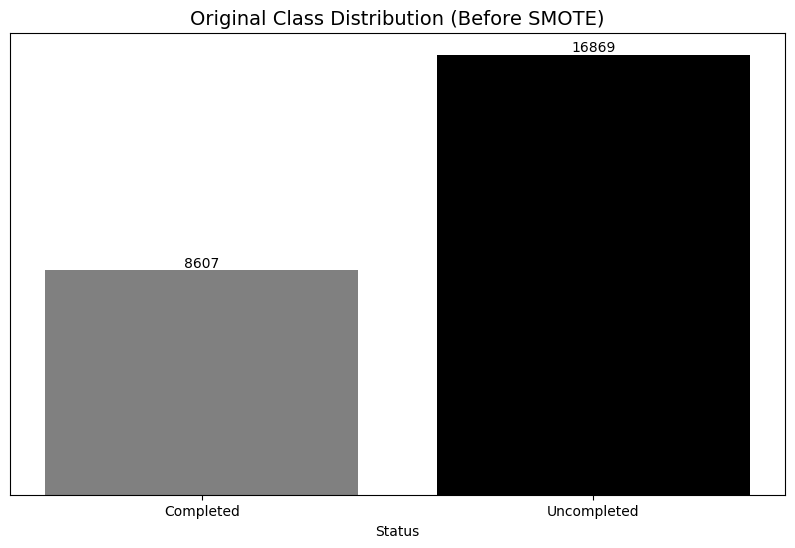

In [25]:
plt.figure(figsize=(10, 6))
plt.bar(['Completed', 'Uncompleted'], [sum(y_train == 0), sum(y_train == 1)], color=['gray', 'black'])
plt.title('Original Class Distribution (Before SMOTE)', fontsize=14)
plt.xlabel('Status')
plt.yticks([])
plt.bar_label(plt.gca().containers[0])
plt.show()

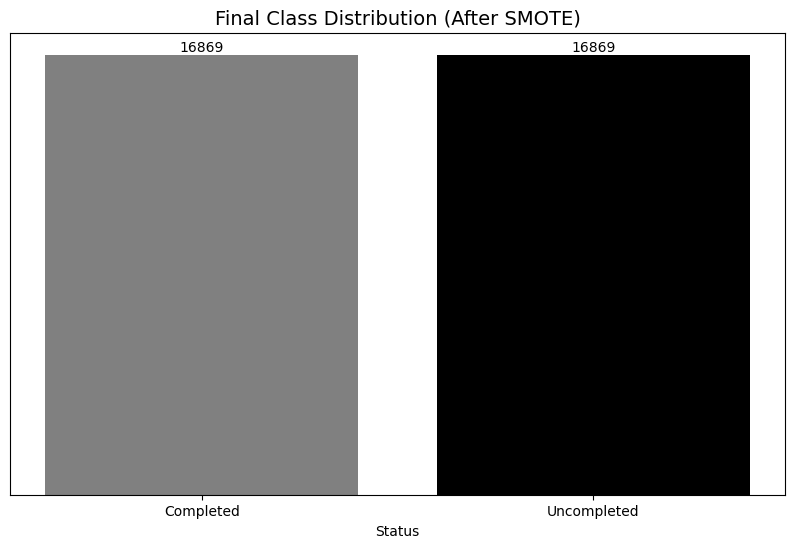

In [26]:
plt.figure(figsize=(10, 6))
plt.bar(['Completed', 'Uncompleted'], [sum(y_train_res == 0), sum(y_train_res == 1)], color=['gray', 'black'])
plt.title('Final Class Distribution (After SMOTE)', fontsize=14)
plt.xlabel('Status')
plt.yticks([])
plt.bar_label(plt.gca().containers[0])
plt.show()

In [27]:
# confirming final columns before training

print(final_df.columns)

Index(['age', 'appointment_month', 'day_of_week', 'is_weekend', 'Target',
       'gender_bin', 'city_Portland', 'city_Seattle', 'city_Spokane',
       'city_Tacoma'],
      dtype='object')


In [28]:
# Training the Forest! 100 trees will learn the patterns in our balanced data

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)

RandomForestClassifier(random_state=42)

In [29]:
# test the model with X_test

y_pred = rf_model.predict(X_test)

In [30]:
# compare 'y_test' (The REAL answers) with 'y_pred' (The AI's guesses)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.67      0.65      2143
           1       0.83      0.79      0.81      4226

    accuracy                           0.75      6369
   macro avg       0.73      0.73      0.73      6369
weighted avg       0.76      0.75      0.76      6369



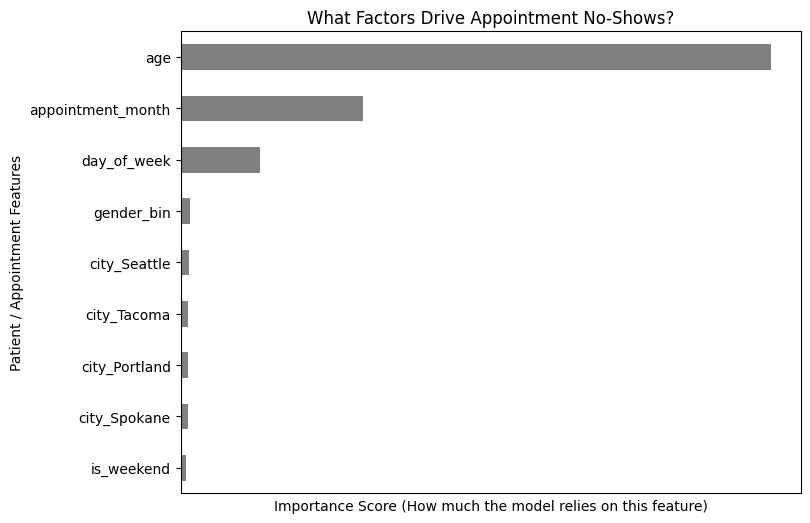

In [31]:
# Plotting Feature Importance to tell us the factors that 'moved the needle' for the AI.

plt.figure(figsize=(8, 6))

importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=True)
feat_importances.plot(kind='barh', color='gray')
plt.xlabel('Importance Score (How much the model relies on this feature)')
plt.xticks([])
plt.ylabel('Patient / Appointment Features')
plt.title("What Factors Drive Appointment No-Shows?")
plt.show()

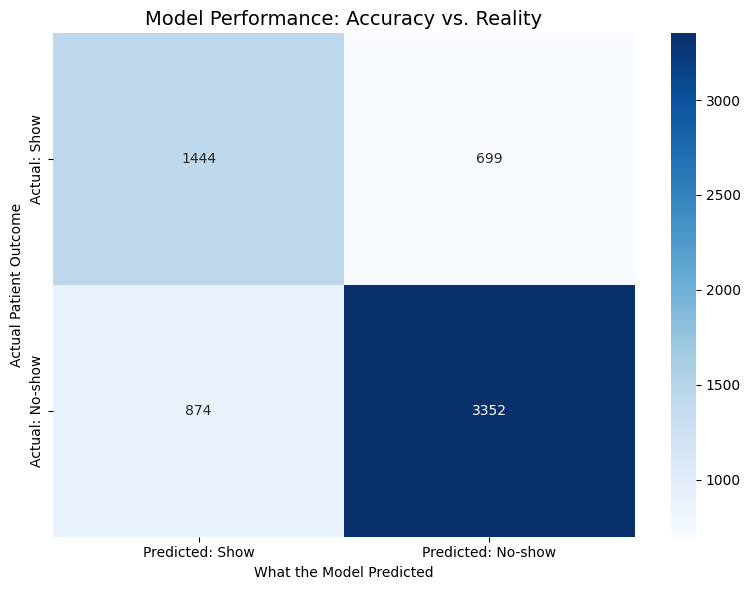

In [32]:
# the truth table to show where the model got confused

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Show', 'Predicted: No-show'],
            yticklabels=['Actual: Show', 'Actual: No-show'])

plt.title('Model Performance: Accuracy vs. Reality', fontsize=14)
plt.ylabel('Actual Patient Outcome')
plt.xlabel('What the Model Predicted')
plt.tight_layout()
plt.show()

In [33]:
# probability and risk scoring

test_probs = rf_model.predict_proba(X_test)[:, 1]

# creates a high risk to flags anyone with a > 70% chance of missing

high_risk_patients = (test_probs > 0.70).astype(int)

# the first 10 patients' risk scores

print("Top 10 Patient Risk Scores:")
print(test_probs[:10])

Top 10 Patient Risk Scores:
[1.         0.76       0.92108333 0.94       0.13127778 0.05666667
 0.74381742 0.08       0.204      0.99      ]


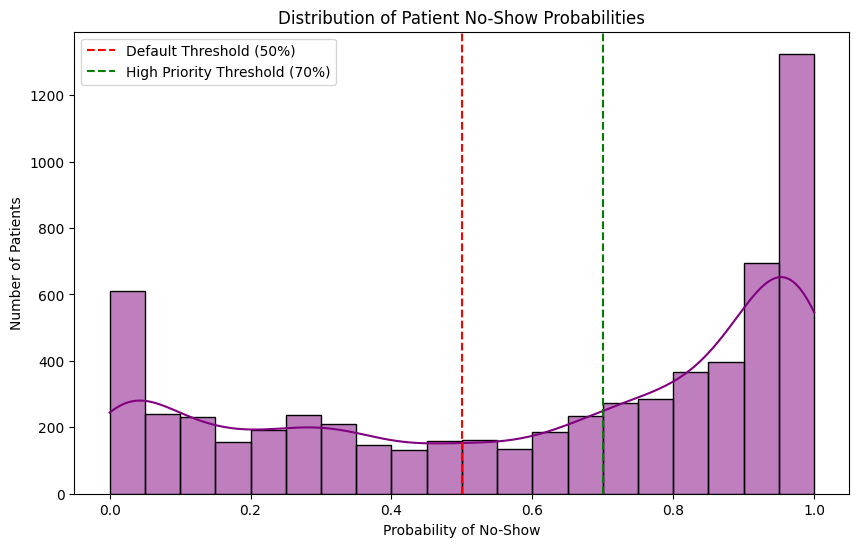

In [34]:
# visualizing the risk distribution

plt.figure(figsize=(10, 6))
sns.histplot(test_probs, bins=20, kde=True, color='purple')
plt.axvline(0.5, color='red', linestyle='--', label='Default Threshold (50%)')
plt.axvline(0.7, color='green', linestyle='--', label='High Priority Threshold (70%)')
plt.title('Distribution of Patient No-Show Probabilities')
plt.xlabel('Probability of No-Show')
plt.ylabel('Number of Patients')
plt.legend()
plt.show()

In [35]:
# linking predictions back to healthcare_df (main  df)

result_df = pd.DataFrame({
    'Probability_Of_NoShow': test_probs
}, index=X_test.index)

# connect result_df to main healthcare_df

final_output = healthcare_df.join(result_df)

# print top 5 highest-risk patients

print(final_output[['patient_id', 'age', 'gender', 'city', 'Probability_Of_NoShow']].sort_values(by='Probability_Of_NoShow', ascending=False).head(10))

       patient_id  age gender      city  Probability_Of_NoShow
31570        1970   13      M  Portland                    1.0
92            783   59      M    Tacoma                    1.0
91            783   59      M    Tacoma                    1.0
17196        1775   22      M   Olympia                    1.0
30891        3989   14      M   Spokane                    1.0
31281        3631   43      M   Spokane                    1.0
31256        1744   75      F    Tacoma                    1.0
31253        1744   75      F    Tacoma                    1.0
31206        1851   57      M   Seattle                    1.0
321          4921   61      F   Seattle                    1.0
